In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
from collections import defaultdict
import glob
from tqdm import tqdm
import gc
import shutil
import random
from tensorflow.keras.utils import register_keras_serializable

# --- Google Drive Mount and Data Extraction ---
from google.colab import drive
drive.mount('/content/drive')

# Ensure the .tar.gz file exists at this path
print("Extracting dataset...")
!tar -xvzf '/content/drive/MyDrive/OCT2017 (1).tar.gz' -C /content/
print("Dataset extracted.")

Streaming output truncated to the last 5000 lines.
./OCT2017/train/CNV/CNV-6666538-574.jpeg
./OCT2017/train/CNV/CNV-1188386-603.jpeg
./OCT2017/train/CNV/CNV-1781140-74.jpeg
./OCT2017/train/CNV/CNV-7315522-30.jpeg
./OCT2017/train/CNV/CNV-8082730-14.jpeg
./OCT2017/train/CNV/CNV-1781140-180.jpeg
./OCT2017/train/CNV/CNV-7907754-413.jpeg
./OCT2017/train/CNV/CNV-137351-113.jpeg
./OCT2017/train/CNV/CNV-4244160-134.jpeg
./OCT2017/train/CNV/CNV-9642260-283.jpeg
./OCT2017/train/CNV/CNV-732516-169.jpeg
./OCT2017/train/CNV/CNV-2192440-174.jpeg
./OCT2017/train/CNV/CNV-9206459-7.jpeg
./OCT2017/train/CNV/CNV-9598696-112.jpeg
./OCT2017/train/CNV/CNV-1651625-37.jpeg
./OCT2017/train/CNV/CNV-172472-51.jpeg
./OCT2017/train/CNV/CNV-1894770-40.jpeg
./OCT2017/train/CNV/CNV-4612183-53.jpeg
./OCT2017/train/CNV/CNV-9642260-241.jpeg
./OCT2017/train/CNV/CNV-8184974-60.jpeg
./OCT2017/train/CNV/CNV-2158821-4.jpeg
./OCT2017/train/CNV/CNV-9997680-79.jpeg
./OCT2017/train/CNV/CNV-4951152-24.jpeg
./OCT2017/train/CNV/CNV

In [2]:
#@title **SPLITTING DIRECTORY**
import os
import shutil
import random

# === Input Paths ===
test_dir_full = "/content/OCT2017/test"

import os
import shutil
import random
from tqdm import tqdm

# === Set source and target directories ===
original_train_dir = "/content/OCT2017/train"
split_root = "/content/OCT_split"
train_split_dir = os.path.join(split_root, "train")
val_split_dir = os.path.join(split_root, "val")

# === Create target directories ===
os.makedirs(train_split_dir, exist_ok=True)
os.makedirs(val_split_dir, exist_ok=True)

# === Set random seed for reproducibility ===
random.seed(42)

# === Split images for each class ===
SPLIT_RATIO = 0.8  # 80% train, 20% val

for class_name in os.listdir(original_train_dir):
    class_path = os.path.join(original_train_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * SPLIT_RATIO)
    train_images = images[:split_index]
    val_images = images[split_index:]

    train_class_dir = os.path.join(train_split_dir, class_name)
    val_class_dir = os.path.join(val_split_dir, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)

    for img_name in tqdm(train_images, desc=f"Train {class_name}"):
        shutil.copy(os.path.join(class_path, img_name), os.path.join(train_class_dir, img_name))

    for img_name in tqdm(val_images, desc=f"Val {class_name}"):
        shutil.copy(os.path.join(class_path, img_name), os.path.join(val_class_dir, img_name))

print("\n✅ Train/Val split complete.")

Val DRUSEN: 100%|██████████| 1724/1724 [00:00<00:00, 7892.82it/s]


✅ Train/Val split complete.


In [4]:
#@title **LOADING**
import tensorflow as tf

# === Paths to subdataset directories ===
train_dir = "/content/OCT_split/train"
val_dir = "/content/OCT_split/val"
test_dir = "/content/OCT2017/test"

# === Hyperparameters ===
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

# === Load Datasets from Folders (in Grayscale) ===
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False,
    seed=SEED
)

# === Extract class names and number of classes ===
class_names = train_ds.class_names
print("Class names:", class_names)
NUM_CLASSES = len(class_names)

# === Convert labels to one-hot ===
def one_hot_encode(image, label):
    return image, tf.one_hot(label, depth=NUM_CLASSES)

# === Apply one-hot encoding ===
train_ds = train_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)

# === Prefetch ===
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 66786 files belonging to 4 classes.
Found 16698 files belonging to 4 classes.
Found 1000 files belonging to 4 classes.
Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [6]:
# @title **MODEL**
from tensorflow.keras import regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model, Input

LEARNING_RATE=0.001
MODEL_SAVE_PATH="new_model_path.keras"
RANDOM_SEED=42
EPOCHS=30
BATCH_SIZE=32

# --- Proposed Custom CNN Model Architecture (from previous turns) ---
# Ensure these are registered for saving/loading the model properly

@register_keras_serializable()
def build_resnet_model(input_shape=(128, 128, 1), num_classes=4):
    # Define the input layer
    inputs = Input(shape=input_shape)

    # Load ResNet50 without top layer, with pretrained ImageNet weights
    base_model = ResNet50(include_top=False, weights=None, input_tensor=inputs)

    # Add classification head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


print("\n--- Building Proposed Custom CNN Model ---")
# Input shape is (height, width, channels)
model = build_resnet_model(input_shape=(128, 128, 1), num_classes=NUM_CLASSES)

model.summary()

# --- Compile the Model ---
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- Define Callbacks for Training ---
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [checkpoint]

# --- Train the Model ---
print("\n--- Training Proposed Custom CNN Model ---")
history = model.fit(
    train_ds, # Use image data here
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds, # Use image data here
    callbacks=callbacks,
    verbose=1
)

# --- Load the Best Model and Evaluate on Test Set ---
print(f"\n--- Loading the best model from {MODEL_SAVE_PATH} and evaluating on Test Set ---")



best_model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    compile=True, # Ensure the loaded model is compiled
    safe_mode=False, # Required for custom objects, as they might not be in safe_mode
)


--- Building Proposed Custom CNN Model ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,107,012 (91.96 MB)

 Trainable params: 24,053,892 (91.76 MB)

 Non-trainable params: 53,120 (207.50 KB)


--- Training Proposed Custom CNN Model ---
Epoch 1/30
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6807 - loss: 1.0127
Epoch 1: val_accuracy improved from -inf to 0.68996, saving model to new_model_path.keras
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 156s 46ms/step - accuracy: 0.6807 - loss: 1.0126 - val_accuracy: 0.6900 - val_loss: 1.6990
Epoch 2/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8669 - loss: 0.4132
Epoch 2: val_accuracy did not improve from 0.68996
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 65s 31ms/step - accuracy: 0.8669 - loss: 0.4132 - val_accuracy: 0.6250 - val_loss: 1.8367
Epoch 3/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9010 - loss: 0.3204
Epoch 3: val_accuracy did not improve from 0.68996
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 65s 31ms/step - accuracy: 0.9010 - loss: 0.3204 - val_accuracy: 0.3513 - val_loss: 5.8250
Epoch 4/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8787 - loss: 0.3751
Epoch 4: val_accuracy improved from 0.68996 

In [7]:
best_model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    compile=True, # Ensure the loaded model is compiled
    safe_mode=False, # Required for custom objects, as they might not be in safe_mode
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.9865 - loss: 0.0346

Test Loss: 0.0542
Test Accuracy: 0.9790


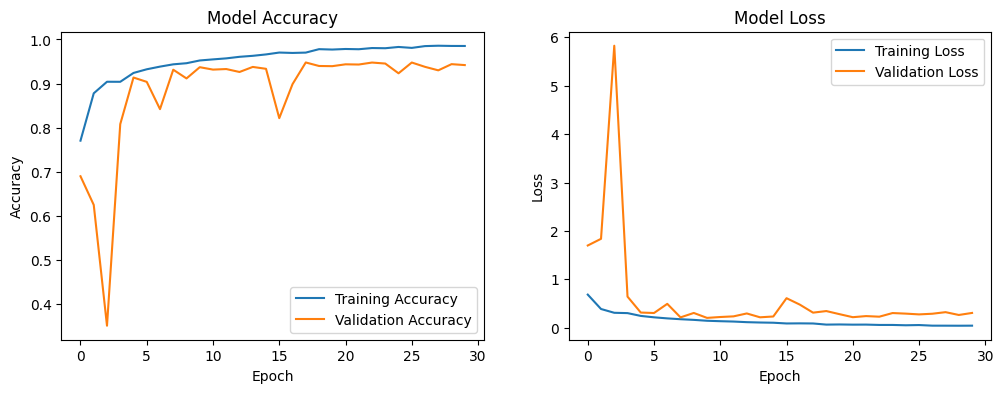


Model training and evaluation complete.


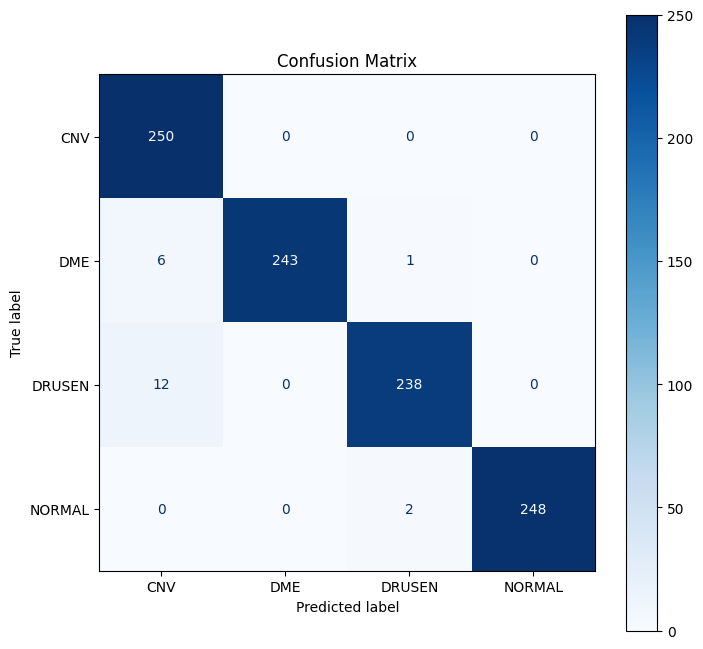


--- Classification Report (Macro Averages) ---
              precision    recall  f1-score   support

         CNV     0.9328    1.0000    0.9653       250
         DME     1.0000    0.9720    0.9858       250
      DRUSEN     0.9876    0.9520    0.9695       250
      NORMAL     1.0000    0.9920    0.9960       250

    accuracy                         0.9790      1000
   macro avg     0.9801    0.9790    0.9791      1000
weighted avg     0.9801    0.9790    0.9791      1000


Overall Test Accuracy: 0.9790
Overall Test Loss: 0.0542


In [8]:
#@title **EVALUATION VISUALISATION**
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1) # Use image data here
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Optional: Plot training history ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\nModel training and evaluation complete.")

import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# === Collect true labels and predicted labels from test_ds ===
y_true_labels = []
y_pred_labels = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_labels.extend(np.argmax(preds, axis=1))
    y_true_labels.extend(np.argmax(labels.numpy(), axis=1))  # labels are one-hot encoded

y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# === Define class names (must match train_ds.class_names order) ===
class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL'] # Adjust if needed

# === Confusion Matrix ===
cm = confusion_matrix(y_true_labels, y_pred_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix')
plt.show()

# === Classification Report ===
print("\n--- Classification Report (Macro Averages) ---")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names, digits=4))

# === Optional: Print previously computed test accuracy/loss ===
print(f"\nOverall Test Accuracy: {test_accuracy:.4f}")
print(f"Overall Test Loss: {test_loss:.4f}")

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# === Collect true labels and predicted labels from test_ds ===
y_true_labels = []
y_pred_labels = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_labels.extend(np.argmax(preds, axis=1))
    y_true_labels.extend(np.argmax(labels.numpy(), axis=1))

# Convert to NumPy arrays
y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# === Print classification report ===
class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']  # Update if needed
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, digits=4)
print("\n--- Classification Report ---")
print(report)

# === Print individual metrics ===
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision = precision_score(y_true_labels, y_pred_labels, average='macro')
recall = recall_score(y_true_labels, y_pred_labels, average='macro')
f1 = f1_score(y_true_labels, y_pred_labels, average='macro')

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")



--- Classification Report ---
              precision    recall  f1-score   support

         CNV     0.9328    1.0000    0.9653       250
         DME     1.0000    0.9720    0.9858       250
      DRUSEN     0.9876    0.9520    0.9695       250
      NORMAL     1.0000    0.9920    0.9960       250

    accuracy                         0.9790      1000
   macro avg     0.9801    0.9790    0.9791      1000
weighted avg     0.9801    0.9790    0.9791      1000


Accuracy:  0.9790
Precision: 0.9801
Recall:    0.9790
F1-Score:  0.9791


In [12]:
import tensorflow as tf
import numpy as np
import time
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# === PARAMETER COUNT ===
param_count = best_model.count_params()
print(f"🔢 Parameter Count: {param_count:,}")

# === FLOPs ===
def calculate_flops(model):
    # Create a ConcreteFunction from the Keras model
    concrete_func = tf.function(lambda x: model(x)).get_concrete_function(
        tf.TensorSpec([1] + list(model.input.shape[1:]), model.input.dtype)
    )

    # Convert to frozen graph
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    # Use tf.compat.v1.profiler to count FLOPs
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )
    return flops.total_float_ops if flops is not None else 0

flops = calculate_flops(best_model)
print(f"⚙️ FLOPs: {flops:,}")

# === INFERENCE TIME ===
inference_times = []
image_count = 0

for images, labels in test_ds.take(10):  # Adjust for more/less timing
    for i in range(images.shape[0]):
        input_img = tf.expand_dims(images[i], axis=0)
        _ = best_model.predict(input_img, verbose=0)  # Warm-up
        start_time = time.time()
        _ = best_model.predict(input_img, verbose=0)
        end_time = time.time()
        inference_times.append((end_time - start_time) * 1000)  # ms
        image_count += 1

average_inference_time = np.mean(inference_times)
print(f"⏱️ Average Inference Time per image: {average_inference_time:.2f} ms over {image_count} images")


🔢 Parameter Count: 24,107,012


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


⚙️ FLOPs: 2,480,781,208
⏱️ Average Inference Time per image: 73.31 ms over 320 images
